In [1]:
import kagglehub
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os
from os import path
from  glob import glob
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from audiomentations import Compose, AddGaussianNoise, PitchShift, HighPassFilter

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
path = kagglehub.dataset_download("warcoder/cats-vs-dogs-vs-birds-audio-classification")

print("Path to dataset files:", path)

Path to dataset files: /home/pavel/.cache/kagglehub/datasets/warcoder/cats-vs-dogs-vs-birds-audio-classification/versions/1


In [41]:
files_bird = [f for f in os.listdir(bird) if f.endswith('.wav')]
files_dog = [f for f in os.listdir(dog) if f.endswith('.wav')]
files_cat = [f for f in os.listdir(cat) if f.endswith('.wav')]

Обрабатываем файл: /home/pavel/.cache/kagglehub/datasets/warcoder/cats-vs-dogs-vs-birds-audio-classification/versions/1/Animals/bird/f88f97a7_nohash_0.wav


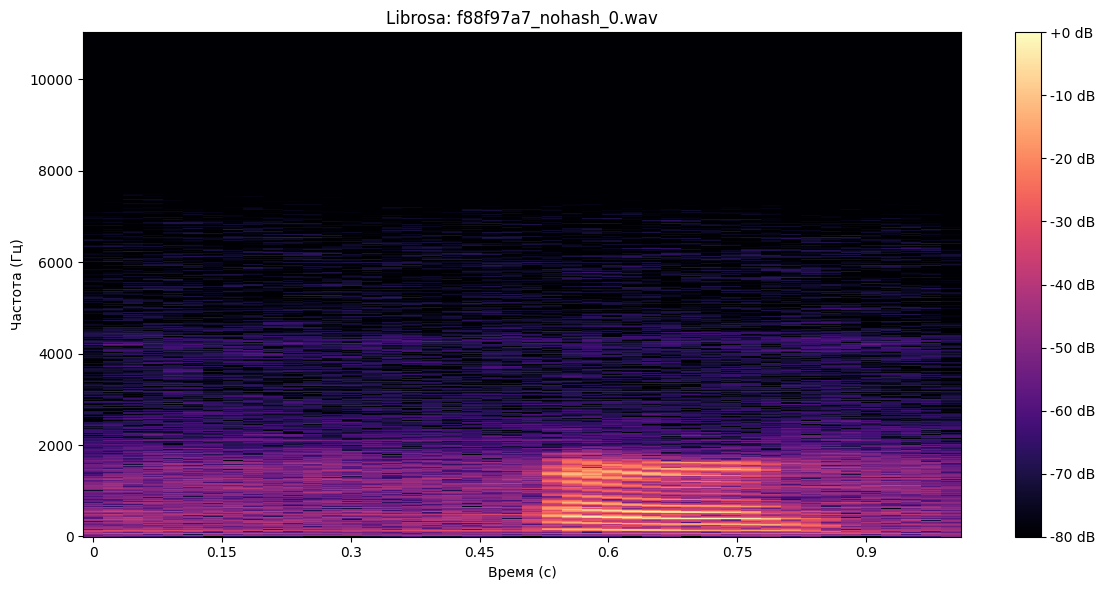

In [46]:
# Librosa
audio_file = os.path.join(bird, files_bird[4])
print(f"Обрабатываем файл: {audio_file}")
y, sr = librosa.load(audio_file, sr=22050, mono=True, duration=5)
D = librosa.stft(y)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)     ####
plt.figure(figsize=(12, 6))
librosa.display.specshow(S_db, sr=sr, hop_length=512, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Librosa: {files[4]}')
plt.xlabel('Время (с)')
plt.ylabel('Частота (Гц)')
plt.tight_layout()
plt.show()

Обрабатываем файл: /home/pavel/.cache/kagglehub/datasets/warcoder/cats-vs-dogs-vs-birds-audio-classification/versions/1/Animals/bird/f88f97a7_nohash_0.wav


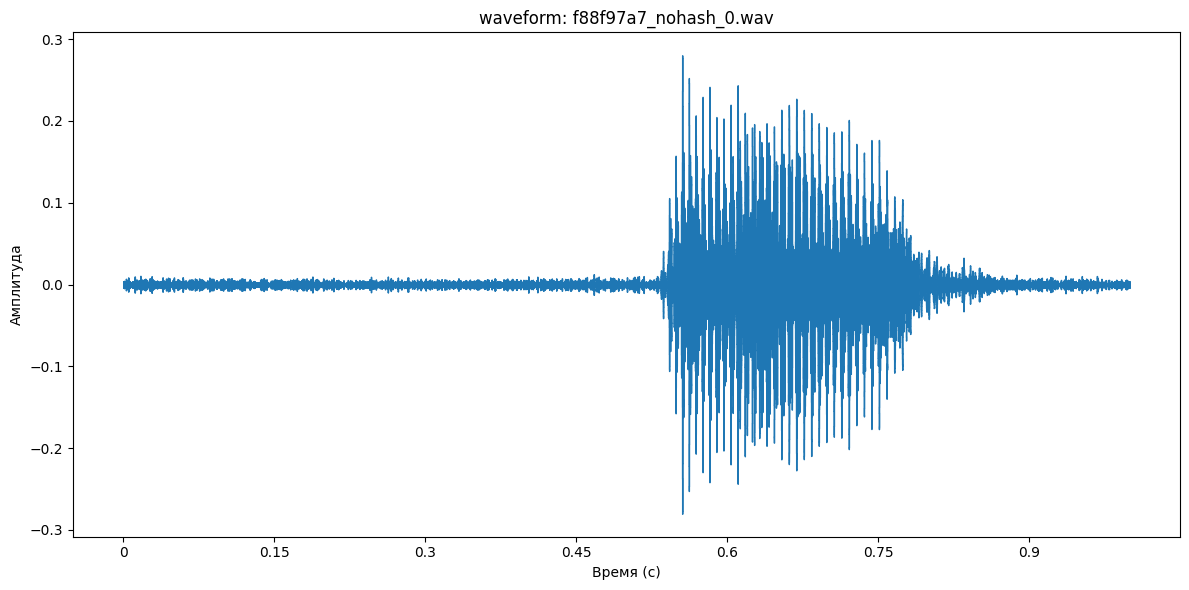

In [90]:
# waveform
audio_file = os.path.join(bird, files[4])
print(f"Обрабатываем файл: {audio_file}")
y, sr = librosa.load(audio_file, duration=5)
plt.figure(figsize=(12, 6))
librosa.display.waveshow(y, sr=sr)
plt.title(f'waveform: {files[4]}')
plt.xlabel('Время (с)')
plt.ylabel('Амплитуда')
plt.tight_layout()
plt.show()

Обрабатываем файл: /home/pavel/.cache/kagglehub/datasets/warcoder/cats-vs-dogs-vs-birds-audio-classification/versions/1/Animals/bird/f88f97a7_nohash_0.wav


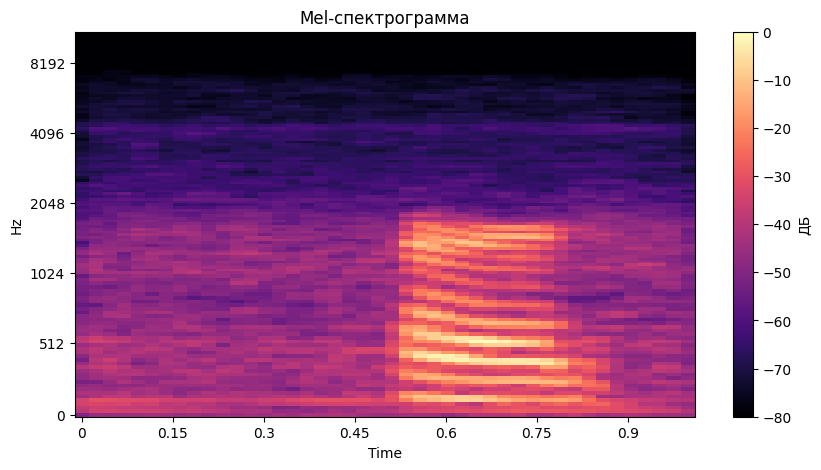

In [58]:
# log - Mel-спектрограмма
audio_file = os.path.join(bird, files[4])
print(f"Обрабатываем файл: {audio_file}")
S_mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
plt.figure(figsize=(10, 5))
librosa.display.specshow(S_mel_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(label='ДБ')
plt.title('Mel-спектрограмма')
plt.show()

Обрабатываем файл: /kaggle/input/cats-vs-dogs-vs-birds-audio-classification/Animals/bird/84bf12ff_nohash_0.wav


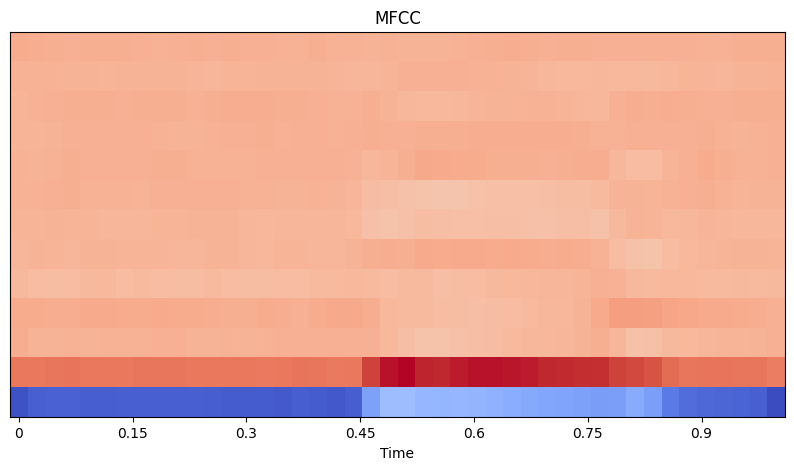

In [51]:
# MFCC
audio_file = os.path.join(bird, files[4])
print(f"Обрабатываем файл: {audio_file}")
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
plt.figure(figsize=(10, 5))
librosa.display.specshow(mfccs, sr=sr, x_axis='time')
plt.title('MFCC')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

In [5]:
full_path = os.path.join(path , 'Animals')

In [6]:
class_name = os.listdir(full_path)

In [13]:
class extractor_audiofile:

    def __init__(self,full_path):
        
        self.full_path = full_path
        self.class_name = os.listdir(full_path)
        self.audiomentator = None

    def augumentation_audio(self):
        
        augment_raw_audio = Compose(
            [
            AddGaussianNoise(min_amplitude=0.01, max_amplitude=0.015, p=1),
            PitchShift(min_semitones=-8, max_semitones=8, p=1),
            HighPassFilter(min_cutoff_freq=2000, max_cutoff_freq=4000, p=1)
            ]
        )
        self.audiomentator = augment_raw_audio
        
    def extract_audio_to_vector(self, audioment:int):

        target = []
        audio = []

        for idx,name in enumerate(self.class_name):
            audio_dir = os.path.join(self.full_path, name)
            for file in os.listdir(audio_dir):
                if file.endswith('.wav'):
                    audio_file = os.path.join(audio_dir, file)
                    y, sr = librosa.load(audio_file, sr = 22050, mono= True, duration = 3)
                    
                    if audioment == 0:
                        if len(y) < 110250:
                            y = np.pad(y, (0, 110250 - len(y)))
                        else:
                            y = y[:110250]
                        audio.append(y)
                        target.append(idx)
                        
                    else:
                        augument_audio =  self.audiomentator(y, sr)
                        if len(augument_audio) < 22050:
                            augument_audio = np.pad(augument_audio, (0, 22050 - len(y)))
                        else:
                            augument_audio = augument_audio[:22050]
                            
                        audio.append(augument_audio)
                        target.append(idx)
                        

        return audio, target

    def extract_audio_to_mfccs(self, audioment:int):

        target = []
        audio = []

        for idx, name in enumerate(self.class_name):
            audio_dir = os.path.join(self.full_path, name)
            for file in os.listdir(audio_dir):
                if file.endswith('.wav'):
                    audio_file = os.path.join(audio_dir, file)
                    y, sr = librosa.load(audio_file, sr = 22050, mono = True, duration = 3)
                 
                    if audioment == 0:
                        mfccs = librosa.feature.mfcc(y = y, sr = sr, n_mfcc = 40, hop_length = 512)
                        
                        audio.append(np.mean(mfccs, axis = 1))
                        target.append(idx)
                        
                    else:
                        augument_audio =  self.audiomentator(y, sr)
                        augument_mfccs = librosa.feature.mfcc(y = augument_audio, sr = sr, n_mfcc = 40, hop_length = 512)
                            
                        audio.append(np.mean(augument_mfccs, axis = 1))
                        target.append(idx)
                        

        return audio, target

    def extract_audio_to_mel(self, audioment:int):

        target = []
        audio = []

        for idx, name in enumerate(self.class_name):
            audio_dir = os.path.join(self.full_path, name)
            for file in os.listdir(audio_dir):
                if file.endswith('.wav'):
                    audio_file = os.path.join(audio_dir, file)
                    y, sr = librosa.load(audio_file, sr = 22050, mono = True, duration = 3)

                    if audioment == 0:
                        
                        S_mel = librosa.feature.melspectrogram(y = y, sr = sr, n_mels = 40, hop_length=512)
                        target.append(idx)
                        audio.append(np.mean(S_mel, axis = 1))
                        
                    else:
                        augument_audio = self.audiomentator(y, sr)
                        augument_S_mel = librosa.feature.melspectrogram(y = augument_audio, sr = sr, n_mels = 40, hop_length=512)
                        target.append(idx)
                        audio.append(np.mean(augument_S_mel, axis = 1))

        return audio, target

    def extract_audio_to_log_mel(self, audioment:int):

        target = []
        audio = []

        for idx, name in enumerate(self.class_name):
            audio_dir = os.path.join(self.full_path,name)
            for file in os.listdir(audio_dir):
                if file.endswith('.wav'):
                    audio_file = os.path.join(audio_dir, file)
                    y, sr = librosa.load(audio_file, sr = 22050, mono = True, duration = 3)
                    if audioment == 0:
                        
                        S_mel = librosa.feature.melspectrogram(y = y, sr = sr, n_mels = 128, hop_length=512)
                        S_mel_db = librosa.power_to_db(S_mel, ref=np.max)
                        audio.append(np.mean(S_mel_db, axis = 1))
                        target.append(idx)
                    else:
                        augument_audio = self.audiomentator(y, sr)
                        augument_S_mel = librosa.feature.melspectrogram(y = augument_audio, sr = sr, n_mels = 40, hop_length=512)
                        augument_S_mel_db = librosa.power_to_db(augument_S_mel, ref=np.max)
                        audio.append(np.mean(augument_S_mel_db, axis = 1))
                        target.append(idx)

        return audio, target


In [14]:
extractor_audio = extractor_audiofile(full_path)
extractor_audio.augumentation_audio()

In [15]:
waveform, target_waveform = extractor_audio.extract_audio_to_vector(audioment = 0)
augument_waveform, augument_target_waveform = extractor_audio.extract_audio_to_vector(audioment = 1)

In [16]:
mfccs, target_mfccs = extractor_audio.extract_audio_to_mfccs(audioment = 0)
augument_mfccs, augument_target_mfccs = extractor_audio.extract_audio_to_mfccs(audioment = 1)

In [17]:
mel, target_mel = extractor_audio.extract_audio_to_mel(audioment = 0)
augument_mel, augument_target_mel = extractor_audio.extract_audio_to_mel(audioment = 1)

In [18]:
log_mel, target_log_mel = extractor_audio.extract_audio_to_log_mel(audioment = 0)
augument_log_mel, augument_target_log_mel = extractor_audio.extract_audio_to_log_mel(audioment = 1)


In [947]:
waveform target_waveform

In [34]:
class random_forestclassifier:
    
    def __init__(self, feature, target,name_feature:str):

        self.feature = np.array(feature)
        self.target = np.array(target)
        self.feature_train = None
        self.feature_test = None
        self.target_train = None
        self.target_test = None
        self.model = None
        self.predict = None
        self.name = name_feature


    def preprocessing(self):
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.feature, self.target, random_state = 42, test_size = 0.2, shuffle = True)

        self.feature_train = X_train
        self.feature_test = X_test
        self.target_train = y_train
        self.target_test = y_test

    def build_model(self):
        
        make_model = RandomForestClassifier(n_estimators = 10, random_state = 42)

        self.model = make_model

    def model_fit_predict(self):

        modelfit = self.model.fit(self.feature_train, self.target_train)
        self.predict = self.model.predict(self.feature_test)

    def accuracy_metrics(self):
        score_list = ['model random_forest', self.name]
        accuracy = accuracy_score(self.target_test, self.predict)
        score_list.append(accuracy)
        
        return score_list

In [30]:
class xgbostclassifier:

    def __init__(self, feature, target, name_feature:str):

        self.feature = np.array(feature)
        self.target = np.array(target)
        self.feature_train = None
        self.feature_test = None
        self.target_train = None
        self.target_test = None
        self.model = None
        self.predict = None
        self.name = name_feature


    def preprocessing(self):
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.feature, self.target, random_state = 42, test_size = 0.2, shuffle = True)

        self.feature_train = X_train
        self.feature_test = X_test
        self.target_train = y_train
        self.target_test = y_test

    def build_model(self):
        
        make_model = XGBClassifier(n_estimators = 10)

        self.model = make_model

    def model_fit_predict(self):

        modelfit = self.model.fit(self.feature_train, self.target_train)
        self.predict = self.model.predict(self.feature_test)

    def accuracy_metrics(self):
        score_list = ['model xgbostclassifier', self.name]
        accuracy = accuracy_score(self.target_test, self.predict)
        score_list.append(accuracy)
        
        return score_list

In [54]:
class catboostclassifier:
    
    def __init__(self, feature, target,name_feature:str):

        self.feature = np.array(feature)
        self.target = np.array(target)
        self.feature_train = None
        self.feature_test = None
        self.target_train = None
        self.target_test = None
        self.model = None
        self.predict = None
        self.name = name_feature


    def preprocessing(self):
        
        X_train, X_test, y_train, y_test = train_test_split(
            self.feature, self.target, random_state = 42, test_size = 0.2, shuffle = True)

        self.feature_train = X_train
        self.feature_test = X_test
        self.target_train = y_train
        self.target_test = y_test

    def build_model(self):
        
        make_model = RandomForestClassifier(n_estimators = 15, random_state = 42)

        self.model = make_model

    def model_fit_predict(self):

        modelfit = self.model.fit(self.feature_train, self.target_train)
        self.predict = self.model.predict(self.feature_test)

    def accuracy_metrics(self):
        score_list = ['model catboost_classifier', self.name]
        accuracy = accuracy_score(self.target_test, self.predict)
        score_list.append(accuracy)
        
        return score_list

In [57]:
xgbost1 = xgbostclassifier(waveform, target_waveform, 'clean waveform' )
xgbost1.preprocessing()
xgbost1.build_model()
xgbost1.model_fit_predict()
accuracy_clean_waveform = xgbost1.accuracy_metrics()

In [58]:
xgbost2 = xgbostclassifier(augument_waveform, augument_target_waveform, 'augument waveform' )
xgbost2.preprocessing()
xgbost2.build_model()
xgbost2.model_fit_predict()
accuracy_augument_waveform = xgbost2.accuracy_metrics()

In [59]:
xgbost3 = xgbostclassifier(mfccs, target_mfccs, 'clean mfccs' )
xgbost3.preprocessing()
xgbost3.build_model()
xgbost3.model_fit_predict()
accuracy_clean_mfccs = xgbost3.accuracy_metrics()

In [60]:
xgbost4 = xgbostclassifier(augument_mfccs, augument_target_mfccs, 'augument_mfccs' )
xgbost4.preprocessing()
xgbost4.build_model()
xgbost4.model_fit_predict()
accuracy_augument_mfccs = xgbost4.accuracy_metrics()

In [61]:
xgbost5 = xgbostclassifier(mel, target_mel, 'clean mel' )
xgbost5.preprocessing()
xgbost5.build_model()
xgbost5.model_fit_predict()
accuracy_clean_mel = xgbost5.accuracy_metrics()

In [62]:
xgbost6 = xgbostclassifier(augument_mel, augument_target_mel, 'augument_mel' )
xgbost6.preprocessing()
xgbost6.build_model()
xgbost6.model_fit_predict()
accuracy_augument_mel = xgbost6.accuracy_metrics()

In [64]:
xgbost7 = xgbostclassifier(log_mel, target_log_mel, 'clean log_mel' )
xgbost7.preprocessing()
xgbost7.build_model()
xgbost7.model_fit_predict()
accuracy_clean_log_mel = xgbost7.accuracy_metrics()

In [65]:
xgbost8 = xgbostclassifier(augument_log_mel, augument_target_log_mel, 'augument_log_mel' )
xgbost8.preprocessing()
xgbost8.build_model()
xgbost8.model_fit_predict()
accuracy_augument_log_mel = xgbost8.accuracy_metrics()

In [66]:
random_forest1 = random_forestclassifier(waveform, target_waveform, 'clean waveform' )
random_forest1.preprocessing()
random_forest1.build_model()
random_forest1.model_fit_predict()
accuracy_random_forest1_clean_waveform = random_forest1.accuracy_metrics()

In [68]:
random_forest2 = random_forestclassifier(augument_waveform, augument_target_waveform, 'augument_waveform' )
random_forest2.preprocessing()
random_forest2.build_model()
random_forest2.model_fit_predict()
accuracy_random_forest_augument_waveform = random_forest2.accuracy_metrics()

In [69]:
random_forest3 = random_forestclassifier(mfccs, target_mfccs, 'clean mfccs' )
random_forest3.preprocessing()
random_forest3.build_model()
random_forest3.model_fit_predict()
accuracy_random_forest_clean_mfccs = random_forest3.accuracy_metrics()

In [71]:
random_forest4 = random_forestclassifier(augument_mfccs, augument_target_mfccs, 'augument_mfccs' )
random_forest4.preprocessing()
random_forest4.build_model()
random_forest4.model_fit_predict()
accuracy_random_forest_augument_mfccs = random_forest4.accuracy_metrics()

In [72]:
random_forest5 = random_forestclassifier(mel, target_mel, 'clean mel' )
random_forest5.preprocessing()
random_forest5.build_model()
random_forest5.model_fit_predict()
accuracy_random_forest_clean_mel = random_forest5.accuracy_metrics()

In [74]:
random_forest6 = random_forestclassifier(augument_mel, augument_target_mel, 'augument_mel' )
random_forest6.preprocessing()
random_forest6.build_model()
random_forest6.model_fit_predict()
accuracy_random_forest_augument_mel = random_forest6.accuracy_metrics()

In [75]:
random_forest7 = random_forestclassifier(log_mel, target_log_mel, 'clean log_mel' )
random_forest7.preprocessing()
random_forest7.build_model()
random_forest7.model_fit_predict()
accuracy_random_forest_clean_log_mel = random_forest7.accuracy_metrics()

In [76]:
random_forest8 = random_forestclassifier(augument_log_mel, augument_target_log_mel, 'augument_log_mel' )
random_forest8.preprocessing()
random_forest8.build_model()
random_forest8.model_fit_predict()
accuracy_random_forest_augument_log_mel = random_forest8.accuracy_metrics()

In [77]:
catboost1 = catboostclassifier(waveform, target_waveform, 'clean waveform' )
catboost1.preprocessing()
catboost1.build_model()
catboost1.model_fit_predict()
accuracy_catboost_clean_waveform = catboost1.accuracy_metrics()

In [78]:
catboost2 = catboostclassifier(augument_waveform, augument_target_waveform, 'augument_target_waveform' )
catboost2.preprocessing()
catboost2.build_model()
catboost2.model_fit_predict()
accuracy_catboost_augument_waveform = catboost2.accuracy_metrics()

In [79]:
catboost3 = catboostclassifier(mfccs, target_mfccs, 'clean mfccs' )
catboost3.preprocessing()
catboost3.build_model()
catboost3.model_fit_predict()
accuracy_catboost_clean_mfccs = catboost3.accuracy_metrics()

In [83]:
catboost4 = catboostclassifier(augument_mfccs, augument_target_mfccs, 'augument_mfccs' )
catboost4.preprocessing()
catboost4.build_model()
catboost4.model_fit_predict()
accuracy_catboost_augument_mfccs = catboost4.accuracy_metrics()

In [81]:
catboost5 = catboostclassifier(mel, target_mel, 'clean mel' )
catboost5.preprocessing()
catboost5.build_model()
catboost5.model_fit_predict()
accuracy_catboost_clean_mel = catboost5.accuracy_metrics()

In [84]:
catboost6 = catboostclassifier(augument_mel, augument_target_mfccs, 'augument_mel' )
catboost6.preprocessing()
catboost6.build_model()
catboost6.model_fit_predict()
accuracy_catboost_augument_mel = catboost6.accuracy_metrics()

In [85]:
catboost7 = catboostclassifier(log_mel, target_log_mel, 'clean log_mel' )
catboost7.preprocessing()
catboost7.build_model()
catboost7.model_fit_predict()
accuracy_catboost_clean_log_mel = catboost7.accuracy_metrics()

In [86]:
catboost8 = catboostclassifier(augument_log_mel, augument_target_log_mel, 'augument_log_mel' )
catboost8.preprocessing()
catboost8.build_model()
catboost8.model_fit_predict()
accuracy_catboost_augument_log_mel = catboost8.accuracy_metrics()

In [94]:
xgboost_accuracy_list = []

In [95]:
xgboost_accuracy_list.append(accuracy_clean_waveform)
xgboost_accuracy_list.append(accuracy_augument_waveform)
xgboost_accuracy_list.append(accuracy_clean_mfccs)
xgboost_accuracy_list.append(accuracy_augument_mfccs)
xgboost_accuracy_list.append(accuracy_clean_mel)
xgboost_accuracy_list.append(accuracy_augument_mel)
xgboost_accuracy_list.append(accuracy_clean_log_mel)
xgboost_accuracy_list.append(accuracy_augument_log_mel)

In [96]:
random_forest_accuracy_list = []  

In [97]:
random_forest_accuracy_list.append(accuracy_random_forest1_clean_waveform)
random_forest_accuracy_list.append(accuracy_random_forest_augument_waveform)
random_forest_accuracy_list.append(accuracy_random_forest_clean_mfccs)
random_forest_accuracy_list.append(accuracy_random_forest_augument_mfccs)
random_forest_accuracy_list.append(accuracy_random_forest_clean_mel)
random_forest_accuracy_list.append(accuracy_random_forest_augument_mel)
random_forest_accuracy_list.append(accuracy_random_forest_clean_log_mel)
random_forest_accuracy_list.append(accuracy_random_forest_augument_log_mel)

In [87]:
catboost_accuracy_list = []   

In [88]:
catboost_accuracy_list.append(accuracy_catboost_clean_waveform)
catboost_accuracy_list.append(accuracy_catboost_augument_waveform)
catboost_accuracy_list.append(accuracy_catboost_clean_mfccs)
catboost_accuracy_list.append(accuracy_catboost_augument_mfccs)
catboost_accuracy_list.append(accuracy_catboost_clean_mel)
catboost_accuracy_list.append(accuracy_catboost_augument_mel)
catboost_accuracy_list.append(accuracy_catboost_clean_log_mel)
catboost_accuracy_list.append(accuracy_catboost_augument_log_mel)

In [98]:
sorted(xgboost_accuracy_list, key=lambda score: score[2])  

[['model xgbostclassifier', 'augument waveform', 0.29508196721311475],
 ['model xgbostclassifier', 'clean waveform', 0.4016393442622951],
 ['model xgbostclassifier', 'augument_mfccs', 0.48360655737704916],
 ['model xgbostclassifier', 'augument_log_mel', 0.5],
 ['model xgbostclassifier', 'augument_mel', 0.5573770491803278],
 ['model xgbostclassifier', 'clean log_mel', 0.6311475409836066],
 ['model xgbostclassifier', 'clean mfccs', 0.7868852459016393],
 ['model xgbostclassifier', 'clean mel', 0.8852459016393442]]

In [99]:
sorted(catboost_accuracy_list, key=lambda score: score[2])  

[['model catboost_classifier', 'clean waveform', 0.4180327868852459],
 ['model catboost_classifier', 'augument_mfccs', 0.45081967213114754],
 ['model catboost_classifier', 'augument_target_waveform', 0.4672131147540984],
 ['model catboost_classifier', 'augument_log_mel', 0.5],
 ['model catboost_classifier', 'augument_mel', 0.5491803278688525],
 ['model catboost_classifier', 'clean log_mel', 0.6639344262295082],
 ['model catboost_classifier', 'clean mfccs', 0.6885245901639344],
 ['model catboost_classifier', 'clean mel', 0.9098360655737705]]

In [100]:
sorted(random_forest_accuracy_list, key=lambda score: score[2])

[['model random_forest', 'clean waveform', 0.4098360655737705],
 ['model random_forest', 'augument_waveform', 0.4180327868852459],
 ['model random_forest', 'augument_log_mel', 0.4344262295081967],
 ['model random_forest', 'augument_mfccs', 0.45081967213114754],
 ['model random_forest', 'augument_mel', 0.5491803278688525],
 ['model random_forest', 'clean log_mel', 0.6147540983606558],
 ['model random_forest', 'clean mfccs', 0.6475409836065574],
 ['model random_forest', 'clean mel', 0.9016393442622951]]